In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate

https://stackoverflow.com/questions/74122850/nonlinear-ode-solver-runge-kutta

In [44]:
class EOSModel:

    def __init__(self, gamma=5./3., M0=10., P0=0.0001, k=0.0001):
        self.gamma = gamma
        self.M0 = M0
        self.P0 = P0
        self.k = k
        self.cv = 1. / self.gamma / (self.gamma - 1.)
        self.e0 = self.energy(1., 1.)
        self.p0 = self.pressure(1., 1.)
  
    def energy(self, T, rho):
        return self.cv * T

    def pressure(self, T, rho):
        return rho * T / self.gamma

    def momentum(self, rho, T):
        """Momentum conservation law"""
        return - (self.pressure(T, rho) - self.p0) + self.M0 ** 2 * (1. - 1. / rho) + (1. / 3.) * self.P0 * (1. - T ** 4)

    def solve_rho(self, T):
        """Solve for rho enforcing momentum conservation"""
        return optimize.root(self.momentum, x0=1., args=(T,))
        
    def model(self, x, T):
        """Non linear ODE system"""
        solution = self.solve_rho(T)
        if not solution.success:
            raise ValueError("Cannot solve rho from momentum")
        rho = solution.x[0]
        return np.array([
            (self.M0 / (4 * self.k * T ** 3)) * (
                self.energy(T, rho) - self.e0
                + self.pressure(T, rho) / rho - self.p0
                + (1. / 2.) * self.M0 ** 2 * (1. / rho - 1.)
                + (4. / 3.) * self.P0 * (T ** 4 / rho - 1.)
            )
        ])

    def solve(self, xmin=-0.25, T0=1.0, n=200):
        """Integrate the model"""
        x = np.linspace(0., xmin, n)
        solution = integrate.solve_ivp(self.model, [x[0], x[-1]], y0=(T0,), method="LSODA", t_eval=x)
        return solution

In [41]:
solver = EOSModel()

In [45]:
solution = solver.solve(T0=25.)
solution

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00 -1.256e-03 ... -2.487e-01 -2.500e-01]
        y: [[ 2.500e+01  2.489e+01 ...  1.000e+00  1.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 142
     njev: 5
      nlu: 5

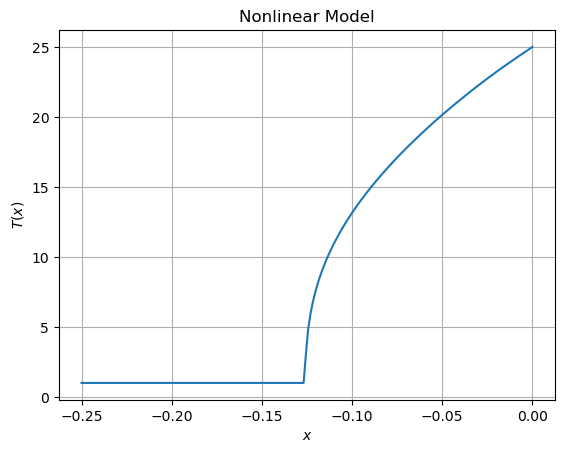

In [47]:
fig, axe = plt.subplots()
axe.plot(solution.t, solution.y.T)
axe.set_title("Nonlinear Model")
axe.set_xlabel("$x$")
axe.set_ylabel("$T(x)$")
axe.grid()